In [2]:
%pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



In [6]:
# Load the datasets
ratings = pd.read_csv("rating.csv")
movies = pd.read_csv("movie.csv")

# Merge datasets on 'movieId'
df = pd.merge(ratings, movies, on='movieId')

# Drop 'timestamp' column
df.drop(columns=['timestamp'], inplace=True)

# Show first few rows
df.head()


,userId,movieId,rating,title,genres
0,1,2,3.5,Jumanji (1995),Adventure|Children|Fantasy
1,1,29,3.5,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
2,1,32,3.5,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,3.5,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,3.5,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Total ratings: 20000263
Total unique users: 138493
Total unique movies: 26744
Average rating: 3.53


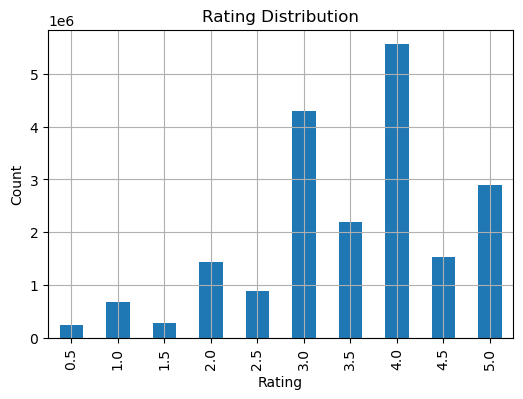

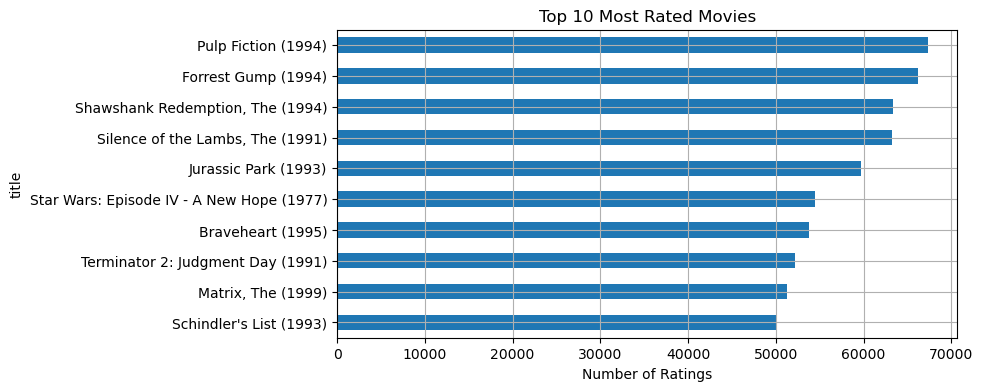

In [19]:
# Show basic info
print(f"Total ratings: {len(df)}")
print(f"Total unique users: {df['userId'].nunique()}")
print(f"Total unique movies: {df['movieId'].nunique()}")
print(f"Average rating: {df['rating'].mean():.2f}")

# Histogram of ratings
plt.figure(figsize=(6, 4))
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Top 10 most rated movies
top_movies = df.groupby('title').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))
top_movies.plot(kind='barh')
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


## 🔄 Data Preprocessing

Before training the models, we perform the following preprocessing steps:

1. **Convert ratings into binary labels**:  
   We classify each rating as "liked" (1) if it’s 4.0 or above, and "not liked" (0) otherwise.  
   This allows us to treat the problem as binary classification.

2. **Encode user and movie IDs**:  
   Since machine learning models can’t work with categorical data directly, we use `LabelEncoder` to convert `userId` and `movieId` into numerical features.

3. **Sample the data**:  
   Because the dataset is very large, we randomly sample 100,000 rows for training and 20,000 for testing.  
   This makes the models faster to train, especially KNN and tree-based methods, without sacrificing too much accuracy.

These steps are repeated for each train-test split configuration (60/40, 70/30, 80/20).


In [20]:
# Define all three split scenarios
splits = {
    '60_40': train_test_split(df, test_size=0.4, random_state=42),
    '70_30': train_test_split(df, test_size=0.3, random_state=42),
    '80_20': train_test_split(df, test_size=0.2, random_state=42)
}

# Example: show size of each split
for name, (train, test) in splits.items():
    print(f"{name} - Train: {len(train)}, Test: {len(test)}")


60_40 - Train: 12000157, Test: 8000106
70_30 - Train: 14000184, Test: 6000079
80_20 - Train: 16000210, Test: 4000053


## 📍 K-Nearest Neighbors (KNN)

In [21]:
collected_results = []


### 🔹 KNN - 60/40 Split

In [22]:
# Use the 60/40 split
train, test = splits['60_40']

# Convert ratings to liked/not liked
train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

# Encode using full dataset
user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])

# ✅ SAMPLE the data to speed up (used for testing)
small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 💤 FULL DATASET VERSION (uncomment if needed)
# X_train = train[['user_enc', 'movie_enc']]
# y_train = train['liked']
# X_test = test[['user_enc', 'movie_enc']]
# y_test = test['liked']

###  Euclidean distance 60/40 k = 5,6,7      

In [23]:
for k in [5, 6, 7]:
    print(f"\n🔹 Euclidean Distance | k = {k}")
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

    
    collected_results.append({
        'Split': '60_40',
        'Distance': 'euclidean',
        'k': k,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4)
    })



🔹 Euclidean Distance | k = 5
Accuracy: 0.5233
              precision    recall  f1-score   support

   Not Liked       0.53      0.52      0.52     10076
       Liked       0.52      0.53      0.53      9924

    accuracy                           0.52     20000
   macro avg       0.52      0.52      0.52     20000
weighted avg       0.52      0.52      0.52     20000


🔹 Euclidean Distance | k = 6
Accuracy: 0.5247
              precision    recall  f1-score   support

   Not Liked       0.52      0.66      0.58     10076
       Liked       0.53      0.39      0.45      9924

    accuracy                           0.52     20000
   macro avg       0.53      0.52      0.51     20000
weighted avg       0.53      0.52      0.52     20000


🔹 Euclidean Distance | k = 7
Accuracy: 0.5248
              precision    recall  f1-score   support

   Not Liked       0.53      0.52      0.52     10076
       Liked       0.52      0.53      0.53      9924

    accuracy                           0.

### Manhattan distance 60/40 k = 5,6,7

In [24]:
for k in [5, 6, 7]:
    print(f"\n🔹 Manhattan Distance | k = {k}")
    model = KNeighborsClassifier(n_neighbors=k, metric='manhattan', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

    
    collected_results.append({
        'Split': '60_40',
        'Distance': 'Manhattan',
        'k': k,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4)
    })



🔹 Manhattan Distance | k = 5
Accuracy: 0.5244
              precision    recall  f1-score   support

   Not Liked       0.53      0.52      0.52     10076
       Liked       0.52      0.53      0.53      9924

    accuracy                           0.52     20000
   macro avg       0.52      0.52      0.52     20000
weighted avg       0.52      0.52      0.52     20000


🔹 Manhattan Distance | k = 6
Accuracy: 0.5261
              precision    recall  f1-score   support

   Not Liked       0.52      0.66      0.59     10076
       Liked       0.53      0.39      0.45      9924

    accuracy                           0.53     20000
   macro avg       0.53      0.53      0.52     20000
weighted avg       0.53      0.53      0.52     20000


🔹 Manhattan Distance | k = 7
Accuracy: 0.5249
              precision    recall  f1-score   support

   Not Liked       0.53      0.52      0.52     10076
       Liked       0.52      0.53      0.53      9924

    accuracy                           0.

### Cosine distance 60/40 k = 5,6,7

In [25]:
for k in [5, 6, 7]:
    print(f"\n🔹 Cosine Distance | k = {k}")
    model = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

    
    collected_results.append({
        'Split': '60_40',
        'Distance': 'Cosine',
        'k': k,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4)
    })



🔹 Cosine Distance | k = 5
Accuracy: 0.5009
              precision    recall  f1-score   support

   Not Liked       0.50      0.50      0.50     10076
       Liked       0.50      0.50      0.50      9924

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000


🔹 Cosine Distance | k = 6
Accuracy: 0.5013
              precision    recall  f1-score   support

   Not Liked       0.50      0.65      0.57     10076
       Liked       0.50      0.35      0.41      9924

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.50      0.50      0.49     20000


🔹 Cosine Distance | k = 7
Accuracy: 0.5003
              precision    recall  f1-score   support

   Not Liked       0.50      0.50      0.50     10076
       Liked       0.50      0.50      0.50      9924

    accuracy                           0.50     20

### 🔹 KNN - 70/30 Split

In [26]:
# Use the 70/30 split
train, test = splits['70_30']


train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)


user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])


small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 💤 FULL DATASET VERSION (uncomment if needed)
# X_train = train[['user_enc', 'movie_enc']]
# y_train = train['liked']
# X_test = test[['user_enc', 'movie_enc']]
# y_test = test['liked']

###  Eclidean distance 70/30 k = 5,6,7

In [27]:

for k in [5, 6, 7]:
    print(f"\n🔹 Euclidean Distance (70/30) | k = {k}")
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

    
    collected_results.append({
        'Split': '70_30',
        'Distance': 'euclidean',
        'k': k,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4)
    })



🔹 Euclidean Distance (70/30) | k = 5
Accuracy: 0.5292
              precision    recall  f1-score   support

   Not Liked       0.53      0.53      0.53     10047
       Liked       0.53      0.53      0.53      9953

    accuracy                           0.53     20000
   macro avg       0.53      0.53      0.53     20000
weighted avg       0.53      0.53      0.53     20000


🔹 Euclidean Distance (70/30) | k = 6
Accuracy: 0.5299
              precision    recall  f1-score   support

   Not Liked       0.53      0.67      0.59     10047
       Liked       0.54      0.39      0.45      9953

    accuracy                           0.53     20000
   macro avg       0.53      0.53      0.52     20000
weighted avg       0.53      0.53      0.52     20000


🔹 Euclidean Distance (70/30) | k = 7
Accuracy: 0.5308
              precision    recall  f1-score   support

   Not Liked       0.53      0.53      0.53     10047
       Liked       0.53      0.54      0.53      9953

    accuracy     

###  Manhattan distance 70/30 k = 5,6,7

In [28]:
for k in [5, 6, 7]:
    print(f"\n🔹 Manhattan Distance (70/30) | k = {k}")
    model = KNeighborsClassifier(n_neighbors=k, metric='manhattan', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

    
    collected_results.append({
        'Split': '70_30',
        'Distance': 'Manhatten',
        'k': k,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4)
    })



🔹 Manhattan Distance (70/30) | k = 5
Accuracy: 0.5302
              precision    recall  f1-score   support

   Not Liked       0.53      0.53      0.53     10047
       Liked       0.53      0.53      0.53      9953

    accuracy                           0.53     20000
   macro avg       0.53      0.53      0.53     20000
weighted avg       0.53      0.53      0.53     20000


🔹 Manhattan Distance (70/30) | k = 6
Accuracy: 0.5324
              precision    recall  f1-score   support

   Not Liked       0.53      0.67      0.59     10047
       Liked       0.54      0.39      0.45      9953

    accuracy                           0.53     20000
   macro avg       0.53      0.53      0.52     20000
weighted avg       0.53      0.53      0.52     20000


🔹 Manhattan Distance (70/30) | k = 7
Accuracy: 0.5343
              precision    recall  f1-score   support

   Not Liked       0.54      0.53      0.53     10047
       Liked       0.53      0.54      0.54      9953

    accuracy     

###  Cosine distance 70/30 k = 5,6,7

In [29]:
for k in [5, 6, 7]:
    print(f"\n🔹 Cosine Distance (70/30) | k = {k}")
    model = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

    
    collected_results.append({
        'Split': '70_30',
        'Distance': 'Cosine',
        'k': k,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4)
    })



🔹 Cosine Distance (70/30) | k = 5
Accuracy: 0.5045
              precision    recall  f1-score   support

   Not Liked       0.51      0.50      0.50     10047
       Liked       0.50      0.51      0.50      9953

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000


🔹 Cosine Distance (70/30) | k = 6
Accuracy: 0.5077
              precision    recall  f1-score   support

   Not Liked       0.51      0.67      0.58     10047
       Liked       0.51      0.35      0.41      9953

    accuracy                           0.51     20000
   macro avg       0.51      0.51      0.49     20000
weighted avg       0.51      0.51      0.49     20000


🔹 Cosine Distance (70/30) | k = 7
Accuracy: 0.5053
              precision    recall  f1-score   support

   Not Liked       0.51      0.51      0.51     10047
       Liked       0.50      0.51      0.50      9953

    accuracy              

### 🔹 KNN - 80/20 Split

In [30]:
# Use the 80/20 split
train, test = splits['80_20']


train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])


small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 💤 FULL DATASET VERSION (uncomment if needed)
# X_train = train[['user_enc', 'movie_enc']]
# y_train = train['liked']
# X_test = test[['user_enc', 'movie_enc']]
# y_test = test['liked']

### Euclidean distance 80/20 k = 5,6,7

In [31]:
for k in [5, 6, 7]:
    print(f"\n🔹 Euclidean Distance (80/20) | k = {k}")
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

    
    collected_results.append({
        'Split': '80_20',
        'Distance': 'euclidean',
        'k': k,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4)
    })



🔹 Euclidean Distance (80/20) | k = 5
Accuracy: 0.5235
              precision    recall  f1-score   support

   Not Liked       0.53      0.53      0.53     10045
       Liked       0.52      0.52      0.52      9955

    accuracy                           0.52     20000
   macro avg       0.52      0.52      0.52     20000
weighted avg       0.52      0.52      0.52     20000


🔹 Euclidean Distance (80/20) | k = 6
Accuracy: 0.5261
              precision    recall  f1-score   support

   Not Liked       0.52      0.67      0.59     10045
       Liked       0.53      0.38      0.44      9955

    accuracy                           0.53     20000
   macro avg       0.53      0.53      0.52     20000
weighted avg       0.53      0.53      0.52     20000


🔹 Euclidean Distance (80/20) | k = 7
Accuracy: 0.5285
              precision    recall  f1-score   support

   Not Liked       0.53      0.54      0.53     10045
       Liked       0.53      0.52      0.52      9955

    accuracy     

### Manhattan distance 80/20 k = 5,6,7

In [32]:
for k in [5, 6, 7]:
    print(f"\n🔹 Manhattan Distance (80/20) | k = {k}")
    model = KNeighborsClassifier(n_neighbors=k, metric='manhattan', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

    
    collected_results.append({
        'Split': '80_20',
        'Distance': 'Manhattan',
        'k': k,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4)
    })



🔹 Manhattan Distance (80/20) | k = 5
Accuracy: 0.5272
              precision    recall  f1-score   support

   Not Liked       0.53      0.53      0.53     10045
       Liked       0.52      0.53      0.53      9955

    accuracy                           0.53     20000
   macro avg       0.53      0.53      0.53     20000
weighted avg       0.53      0.53      0.53     20000


🔹 Manhattan Distance (80/20) | k = 6
Accuracy: 0.5276
              precision    recall  f1-score   support

   Not Liked       0.52      0.68      0.59     10045
       Liked       0.54      0.38      0.44      9955

    accuracy                           0.53     20000
   macro avg       0.53      0.53      0.52     20000
weighted avg       0.53      0.53      0.52     20000


🔹 Manhattan Distance (80/20) | k = 7
Accuracy: 0.5262
              precision    recall  f1-score   support

   Not Liked       0.53      0.53      0.53     10045
       Liked       0.52      0.52      0.52      9955

    accuracy     

### Cosine distance 80/20 k = 5,6,7

In [33]:
for k in [5, 6, 7]:
    print(f"\n🔹 Cosine Distance (80/20) | k = {k}")
    model = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

    
    collected_results.append({
        'Split': '80_20',
        'Distance': 'Cosine',
        'k': k,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4)
    })



🔹 Cosine Distance (80/20) | k = 5
Accuracy: 0.5030
              precision    recall  f1-score   support

   Not Liked       0.51      0.51      0.51     10045
       Liked       0.50      0.50      0.50      9955

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000


🔹 Cosine Distance (80/20) | k = 6
Accuracy: 0.5073
              precision    recall  f1-score   support

   Not Liked       0.51      0.66      0.58     10045
       Liked       0.51      0.35      0.41      9955

    accuracy                           0.51     20000
   macro avg       0.51      0.51      0.49     20000
weighted avg       0.51      0.51      0.49     20000


🔹 Cosine Distance (80/20) | k = 7
Accuracy: 0.5100
              precision    recall  f1-score   support

   Not Liked       0.51      0.51      0.51     10045
       Liked       0.51      0.51      0.51      9955

    accuracy              

In [34]:
results_df = pd.DataFrame(collected_results)
results_df = results_df.sort_values(by=['Split', 'Distance', 'k']).reset_index(drop=True)
results_df


,Split,Distance,k,Accuracy,F1-Score
0,60_40,Cosine,5,0.5009,0.4977
1,60_40,Cosine,6,0.5013,0.4093
2,60_40,Cosine,7,0.5003,0.4968
3,60_40,Manhattan,5,0.5244,0.5268
4,60_40,Manhattan,6,0.5261,0.4476
5,60_40,Manhattan,7,0.5249,0.5256
6,60_40,euclidean,5,0.5233,0.5253
7,60_40,euclidean,6,0.5247,0.4460
8,60_40,euclidean,7,0.5248,0.5271
9,70_30,Cosine,5,0.5045,0.5044


### 📊 KNN Accuracy by Distance Metric (All Splits Combined)

C:\Users\User\AppData\Local\Temp\ipykernel_6976\891431286.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=results_df, x="k", y="Accuracy", hue="Distance", ci=None)


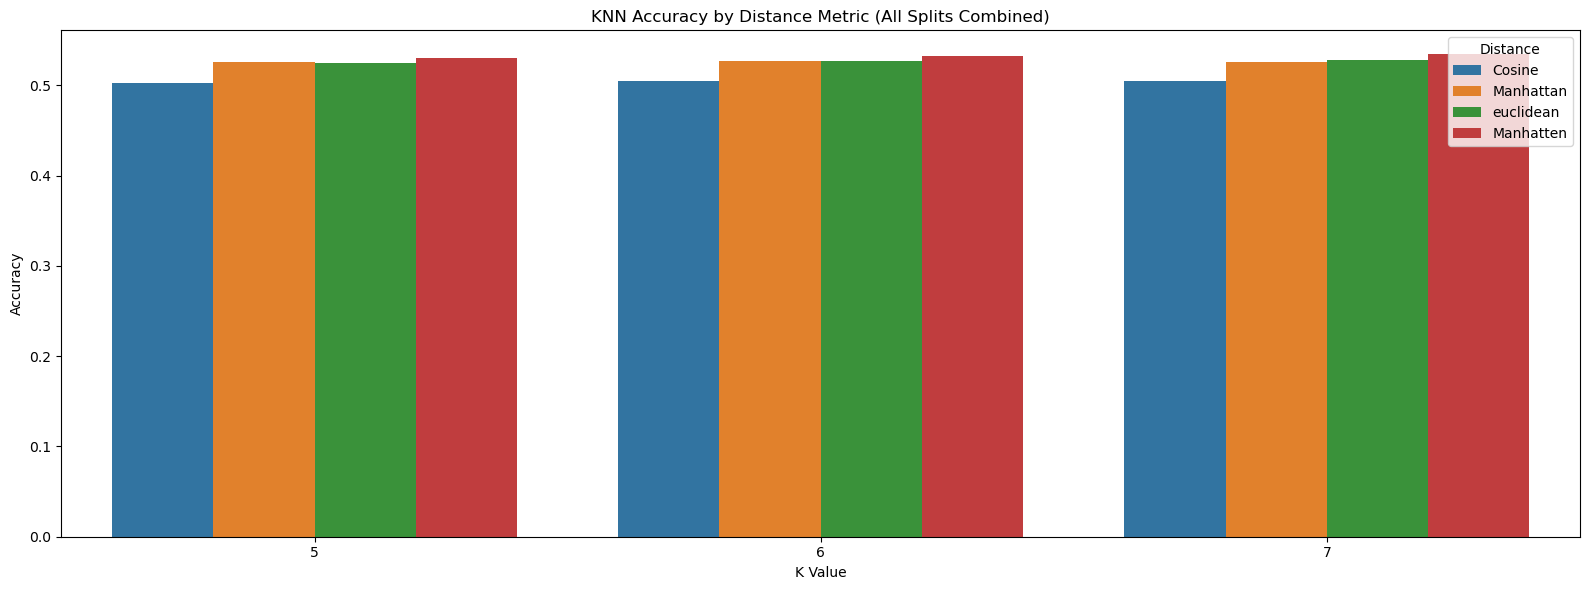

In [35]:
# 📊 Bar Chart: Accuracy for All Splits Combined
plt.figure(figsize=(16, 6))
sns.barplot(data=results_df, x="k", y="Accuracy", hue="Distance", ci=None)
plt.title("KNN Accuracy by Distance Metric (All Splits Combined)")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.legend(title="Distance")
plt.tight_layout()
plt.show()

This bar chart shows the accuracy of the K-Nearest Neighbors (KNN) algorithm for different distance metrics (Cosine, Manhattan, Euclidean) across all tested `k` values (5, 6, 7).

It helps us understand how the choice of distance metric and number of neighbors affects classification performance.


### 🔥 F1-Score Heatmap by Distance, Split, and K

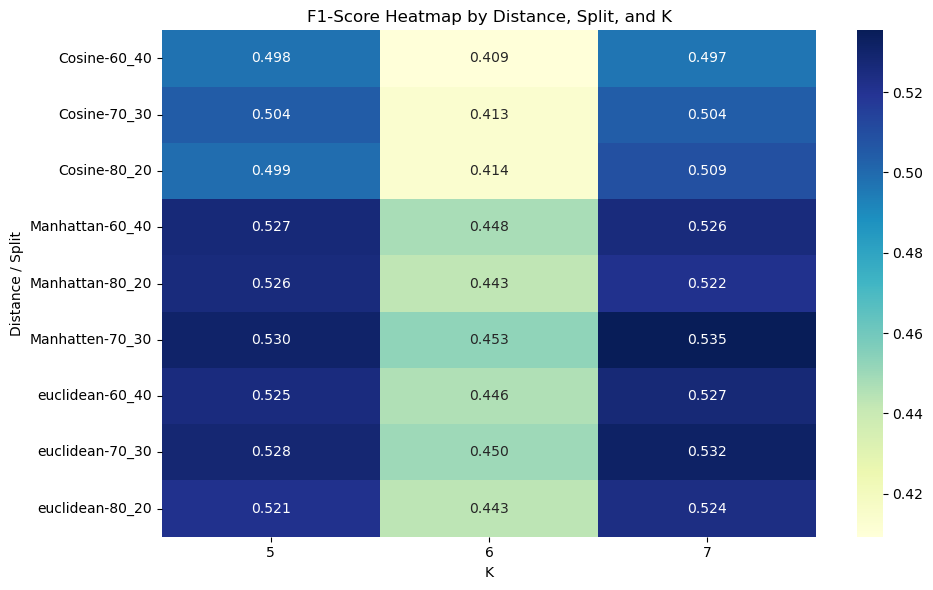

In [36]:
# 📈 Heatmap: F1 Score by Split + Distance + K
pivot_table = results_df.pivot_table(values='F1-Score', index=['Distance', 'Split'], columns='k')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("F1-Score Heatmap by Distance, Split, and K")
plt.ylabel("Distance / Split")
plt.xlabel("K")
plt.tight_layout()
plt.show()


This heatmap displays the F1-scores achieved by the KNN model across all combinations of distance metric, train-test split (60/40, 70/30, 80/20), and `k` values (5, 6, 7).

It allows us to quickly identify the configurations that yield the best balance of precision and recall.

## 🌲 Random Forest Classifier Evaluation


In [43]:
# 📦 Initialize results list
rf_results = []

## 🌲 Random Forest Classifier (60/40 Split)

In [44]:
# Use 60/40 split
train, test = splits['60_40']

# Preprocess
train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])

# ✅ SAMPLE the data
small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 🌲 Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📊 Evaluate
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

# 💾 Save results
rf_results.append({
    'Split': '60_40',
    'Distance': 'Random Forest',  # stays 'Distance' just for consistency with table
    'k': '-',                     # RF doesn’t use k
    'Accuracy': round(acc, 4),
    'F1-Score': round(f1, 4)
})


Accuracy: 0.5716
              precision    recall  f1-score   support

   Not Liked       0.57      0.58      0.58     10076
       Liked       0.57      0.56      0.57      9924

    accuracy                           0.57     20000
   macro avg       0.57      0.57      0.57     20000
weighted avg       0.57      0.57      0.57     20000



## 🌲 Random Forest Classifier (70/30 Split)


In [45]:
# Use 70/30 split
train, test = splits['70_30']

# Preprocess
train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])

# ✅ SAMPLE the data
small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 🌲 Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📊 Evaluate
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

# 💾 Save results
rf_results.append({
    'Split': '70_30',
    'Distance': 'Random Forest',
    'k': '-',
    'Accuracy': round(acc, 4),
    'F1-Score': round(f1, 4)
})


Accuracy: 0.5754
              precision    recall  f1-score   support

   Not Liked       0.58      0.59      0.58     10047
       Liked       0.58      0.56      0.57      9953

    accuracy                           0.58     20000
   macro avg       0.58      0.58      0.58     20000
weighted avg       0.58      0.58      0.58     20000



## 🌲 Random Forest Classifier (80/20 Split)


In [46]:
# Use 80/20 split
train, test = splits['80_20']

# Preprocess
train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])

# ✅ SAMPLE the data
small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 🌲 Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📊 Evaluate
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

# 💾 Save results
rf_results.append({
    'Split': '80_20',
    'Distance': 'Random Forest',
    'k': '-',
    'Accuracy': round(acc, 4),
    'F1-Score': round(f1, 4)
})


Accuracy: 0.5750
              precision    recall  f1-score   support

   Not Liked       0.57      0.59      0.58     10045
       Liked       0.58      0.56      0.57      9955

    accuracy                           0.58     20000
   macro avg       0.58      0.57      0.57     20000
weighted avg       0.58      0.58      0.57     20000



In [47]:
# Convert Random Forest results to DataFrame and display
rf_df = pd.DataFrame(rf_results)
rf_df = rf_df.sort_values(by='Split').reset_index(drop=True)
rf_df


,Split,Distance,k,Accuracy,F1-Score
0,60_40,Random Forest,-,0.5716,0.5659
1,70_30,Random Forest,-,0.5754,0.5682
2,80_20,Random Forest,-,0.5750,0.5658


### 📊 Random Forest Accuracy by Train-Test Split


C:\Users\User\AppData\Local\Temp\ipykernel_6976\328468413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_df, x='Split', y='Accuracy', palette='viridis')


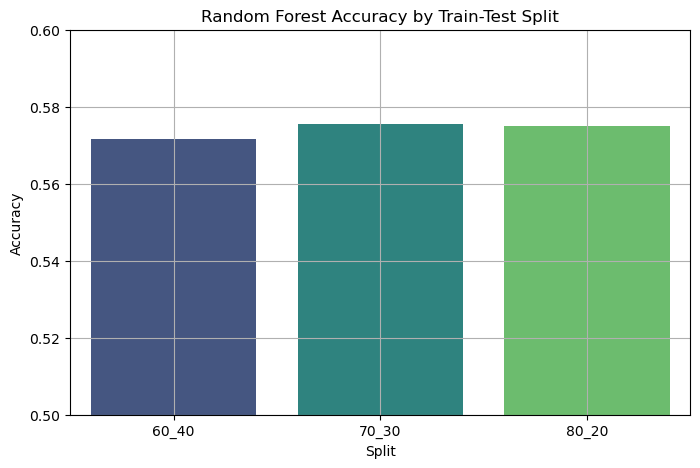

In [48]:
plt.figure(figsize=(8, 5))
sns.barplot(data=rf_df, x='Split', y='Accuracy', palette='viridis')
plt.title("Random Forest Accuracy by Train-Test Split")
plt.ylabel("Accuracy")
plt.xlabel("Split")
plt.ylim(0.5, 0.6)
plt.grid(True)
plt.show()



This bar chart displays the accuracy scores of the Random Forest model across the three different data splits (60/40, 70/30, 80/20).  
It helps us observe how the size of the training data impacts model performance.


### 🔥 Random Forest F1-Score Heatmap

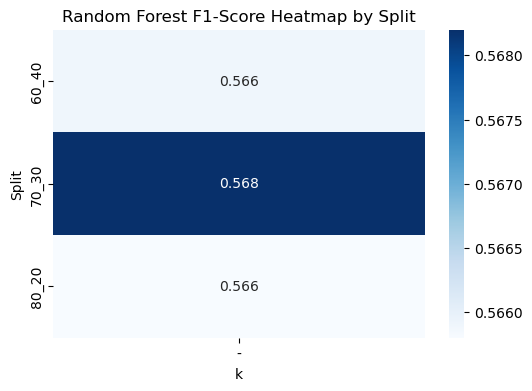

In [49]:
# Pivot for heatmap
rf_heatmap = rf_df.pivot(index='Split', columns='k', values='F1-Score')

plt.figure(figsize=(6, 4))
sns.heatmap(rf_heatmap, annot=True, fmt=".3f", cmap="Blues")
plt.title("Random Forest F1-Score Heatmap by Split")
plt.ylabel("Split")
plt.xlabel("k")
plt.show()

This heatmap shows the F1-score for each train-test split used with the Random Forest model.  
Although Random Forest does not use the `k` parameter like KNN, we maintain the same structure for consistent comparison.  
The F1-score is useful because it considers both precision and recall, especially when the classes are imbalanced.

## 🔥 XGBoost Model

In [50]:
# 🧾 Initialize results list for XGBoost
xgb_results = []


### 📊 XGBoost – 60/40 Split

In [51]:
# Use the 60/40 split
train, test = splits['60_40']

# Convert ratings to binary labels
train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

# Encode user and movie IDs
user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])

# ✅ SAMPLE the data to speed up
small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 💤 FULL DATASET VERSION (uncomment if needed)
# X_train = train[['user_enc', 'movie_enc']]
# y_train = train['liked']
# X_test = test[['user_enc', 'movie_enc']]
# y_test = test['liked']

# ⏳ Train XGBoost Classifier
model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📊 Evaluate
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

# 📥 Save results
xgb_results.append({
    'Split': '60_40',
    'Distance': 'XGBoost',  
    'k': '-',              
    'Accuracy': round(acc, 4),
    'F1-Score': round(f1, 4)
})


c:\Users\User\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:01:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.5779
              precision    recall  f1-score   support

   Not Liked       0.57      0.63      0.60     10076
       Liked       0.58      0.53      0.55      9924

    accuracy                           0.58     20000
   macro avg       0.58      0.58      0.58     20000
weighted avg       0.58      0.58      0.58     20000



### 📊 XGBoost – 70/30 Split

In [52]:
# ⚙️ Use the 70/30 split
train, test = splits['70_30']

# 🎯 Convert ratings to liked/not liked
train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

# ✅ SAMPLE the data to speed up
small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 💤 FULL DATASET VERSION (uncomment if needed)
# X_train = train[['user_enc', 'movie_enc']]
# y_train = train['liked']
# X_test = test[['user_enc', 'movie_enc']]
# y_test = test['liked']


print("\n🔷 XGBoost (70/30)")
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

# 📝 Save results
xgb_results.append({
    'Split': '70_30',
    'Distance': 'XGBoost',  
    'k': '-',                
    'Accuracy': round(acc, 4),
    'F1-Score': round(f1, 4)
})



🔷 XGBoost (70/30)


c:\Users\User\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:01:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.5802
              precision    recall  f1-score   support

   Not Liked       0.58      0.63      0.60     10047
       Liked       0.59      0.53      0.56      9953

    accuracy                           0.58     20000
   macro avg       0.58      0.58      0.58     20000
weighted avg       0.58      0.58      0.58     20000



### 📊 XGBoost – 80/20 Split

In [53]:
# 🧠 Use the 80/20 split
train, test = splits['80_20']

# 🎯 Convert ratings to liked/not liked
train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

# 🔢 Encode using full dataset
user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])

# ✅ SAMPLE the data to speed up
small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 💤 FULL DATASET VERSION (uncomment if needed)
# X_train = train[['user_enc', 'movie_enc']]
# y_train = train['liked']
# X_test = test[['user_enc', 'movie_enc']]
# y_test = test['liked']

# 🚀 Train XGBoost
model = XGBClassifier(n_jobs=-1, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📊 Evaluate
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

# 📝 Save results
xgb_results.append({
    'Split': '80_20',
    'Distance': 'XGBoost',  
    'k': '-',                
    'Accuracy': round(acc, 4),
    'F1-Score': round(f1, 4)
})


Accuracy: 0.5712
              precision    recall  f1-score   support

   Not Liked       0.56      0.65      0.60     10045
       Liked       0.58      0.49      0.53      9955

    accuracy                           0.57     20000
   macro avg       0.57      0.57      0.57     20000
weighted avg       0.57      0.57      0.57     20000



In [54]:
xgb_df = pd.DataFrame(xgb_results)
xgb_df = xgb_df.sort_values(by='Split').reset_index(drop=True)
xgb_df


,Split,Distance,k,Accuracy,F1-Score
0,60_40,XGBoost,-,0.5779,0.5539
1,70_30,XGBoost,-,0.5802,0.5582
2,80_20,XGBoost,-,0.5712,0.5314


## 📊 XGBoost Accuracy by Train-Test Split

C:\Users\User\AppData\Local\Temp\ipykernel_6976\945266362.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgb_df, x='Split', y='Accuracy', palette='viridis')


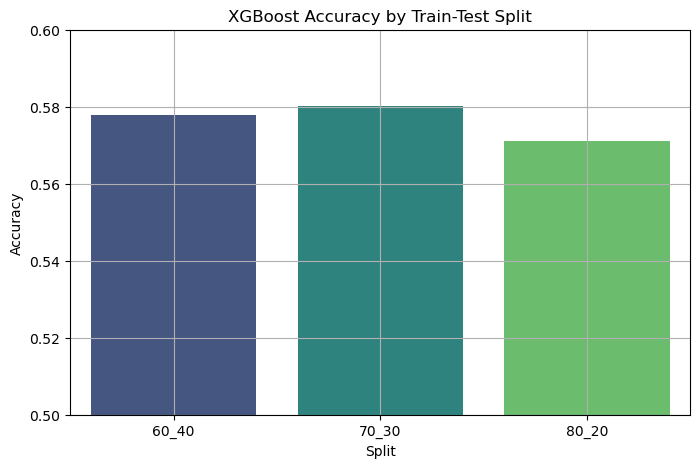

In [55]:
plt.figure(figsize=(8, 5))
sns.barplot(data=xgb_df, x='Split', y='Accuracy', palette='viridis')
plt.title("XGBoost Accuracy by Train-Test Split")
plt.ylabel("Accuracy")
plt.xlabel("Split")
plt.ylim(0.5, 0.6)
plt.grid(True)
plt.show()


This bar chart shows the **accuracy scores** of the XGBoost model across the three different train-test splits (60/40, 70/30, 80/20).  
It helps us understand how the amount of training data affects model performance in terms of overall accuracy.

## 🔥 XGBoost F1-Score Heatmap

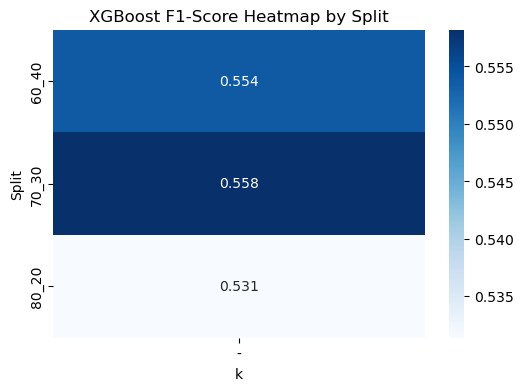

In [56]:
# Pivot for heatmap
xgb_heatmap = xgb_df.pivot(index='Split', columns='k', values='F1-Score')

plt.figure(figsize=(6, 4))
sns.heatmap(xgb_heatmap, annot=True, fmt=".3f", cmap="Blues")
plt.title("XGBoost F1-Score Heatmap by Split")
plt.ylabel("Split")
plt.xlabel("k")
plt.show()


This heatmap presents the **F1-score** for each train-test split evaluated with the XGBoost model.  
Even though XGBoost doesn't use the `k` parameter like KNN, we use `k = '-'` to keep the format uniform.  
F1-score is especially useful when dealing with class imbalance, as it balances precision and recall.

## 🌟 LightGBM

In [57]:
lgb_results = []

## 🌟 LightGBM – 60/40 Split

In [58]:
# 💡 Use the 60/40 split
train, test = splits['60_40']

# 🎯 Convert ratings to liked/not liked
train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

# 🔢 Encode user and movie IDs
user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])

# ✅ SAMPLE the data to speed up
small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 🧠 Train LightGBM Classifier
model = LGBMClassifier(n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📊 Evaluate
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

# 📥 Save results
lgb_results.append({
    'Split': '60_40',
    'Distance': 'LightGBM',  
    'k': '-',                
    'Accuracy': round(acc, 4),
    'F1-Score': round(f1, 4)
})


[LightGBM] [Info] Number of positive: 49935, number of negative: 50065
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499350 -> initscore=-0.002600
[LightGBM] [Info] Start training from score -0.002600
Accuracy: 0.5725
              precision    recall  f1-score   support

   Not Liked       0.57      0.66      0.61     10076
       Liked       0.58      0.49      0.53      9924

    accuracy                           0.57     20000
   macro avg       0.57      0.57      0.57     20000
weighted avg       0.57      0.57      0.57     20000



## 🌟 LightGBM – 70/30 Split


In [59]:
# ⚙️ Use the 70/30 split
train, test = splits['70_30']

# 🔁 Re-encode after split
user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])

# 🎯 Convert ratings to liked/not liked
train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

# ✅ SAMPLE the data to speed up
small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 🚀 Train LightGBM
model = LGBMClassifier(n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📊 Evaluate
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

# 📝 Save results
lgb_results.append({
    'Split': '70_30',
    'Distance': 'LightGBM',
    'k': '-',
    'Accuracy': round(acc, 4),
    'F1-Score': round(f1, 4)
})


[LightGBM] [Info] Number of positive: 49952, number of negative: 50048
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499520 -> initscore=-0.001920
[LightGBM] [Info] Start training from score -0.001920
Accuracy: 0.5858
              precision    recall  f1-score   support

   Not Liked       0.57      0.69      0.63     10047
       Liked       0.61      0.48      0.54      9953

    accuracy                           0.59     20000
   macro avg       0.59      0.59      0.58     20000
weighted avg       0.59      0.59      0.58     20000



## 🌟 LightGBM – 80/20 Split


In [60]:
# ⚙️ Use the 80/20 split
train, test = splits['80_20']

# 🔁 Re-encode after split
user_enc = LabelEncoder()
movie_enc = LabelEncoder()
user_enc.fit(df['userId'])
movie_enc.fit(df['movieId'])

train['user_enc'] = user_enc.transform(train['userId'])
train['movie_enc'] = movie_enc.transform(train['movieId'])
test['user_enc'] = user_enc.transform(test['userId'])
test['movie_enc'] = movie_enc.transform(test['movieId'])

# 🎯 Convert ratings to liked/not liked
train['liked'] = (train['rating'] >= 4.0).astype(int)
test['liked'] = (test['rating'] >= 4.0).astype(int)

# ✅ SAMPLE the data to speed up
small_train = train.sample(n=100_000, random_state=42)
small_test = test.sample(n=20_000, random_state=42)

X_train = small_train[['user_enc', 'movie_enc']]
y_train = small_train['liked']
X_test = small_test[['user_enc', 'movie_enc']]
y_test = small_test['liked']

# 🚀 Train LightGBM
model = LGBMClassifier(n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📊 Evaluate
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Not Liked", "Liked"]))

# 📝 Save results
lgb_results.append({
    'Split': '80_20',
    'Distance': 'LightGBM',
    'k': '-',
    'Accuracy': round(acc, 4),
    'F1-Score': round(f1, 4)
})


[LightGBM] [Info] Number of positive: 49717, number of negative: 50283
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497170 -> initscore=-0.011320
[LightGBM] [Info] Start training from score -0.011320
Accuracy: 0.5824
              precision    recall  f1-score   support

   Not Liked       0.57      0.71      0.63     10045
       Liked       0.61      0.46      0.52      9955

    accuracy                           0.58     20000
   macro avg       0.59      0.58      0.58     20000
weighted avg       0.59      0.58      0.58     20000



In [61]:
lgb_df = pd.DataFrame(lgb_results)
lgb_df = lgb_df.sort_values(by='Split').reset_index(drop=True)
lgb_df


,Split,Distance,k,Accuracy,F1-Score
0,60_40,LightGBM,-,0.5725,0.5309
1,70_30,LightGBM,-,0.5858,0.5367
2,80_20,LightGBM,-,0.5824,0.5216


## 📈 LightGBM Accuracy by Train-Test Split

C:\Users\User\AppData\Local\Temp\ipykernel_6976\735730380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lgb_df, x='Split', y='Accuracy', palette='viridis')


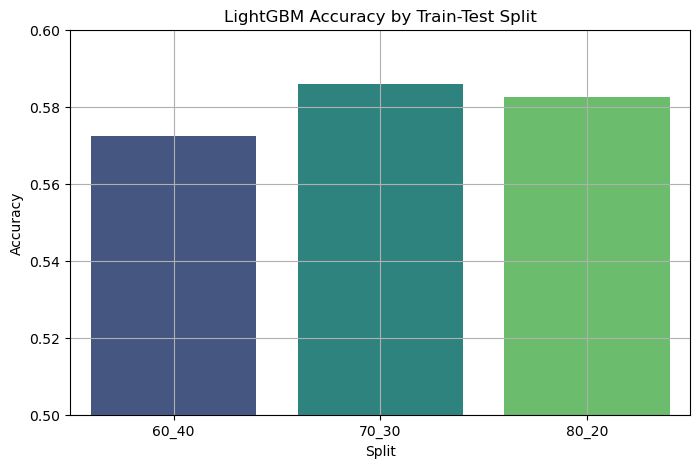

In [62]:
# 📊 LightGBM Accuracy by Train-Test Split
plt.figure(figsize=(8, 5))
sns.barplot(data=lgb_df, x='Split', y='Accuracy', palette='viridis')
plt.title("LightGBM Accuracy by Train-Test Split")
plt.ylabel("Accuracy")
plt.xlabel("Split")
plt.ylim(0.5, 0.6)
plt.grid(True)
plt.show()


This bar chart displays the accuracy scores of the LightGBM model across the three different data splits (60/40, 70/30, 80/20).  
It helps us compare how well the model performs with different amounts of training data.

## 🔥 LightGBM F1-Score Heatmap

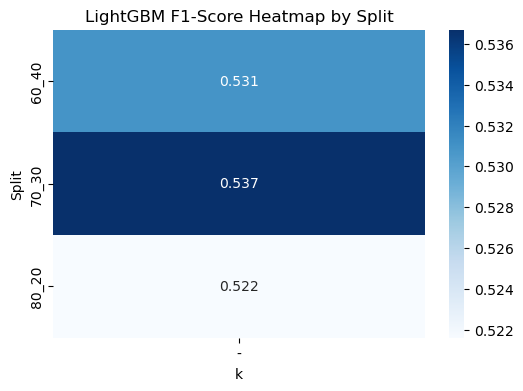

In [63]:
# 🔥 Pivot and Heatmap for F1-Score
lgb_heatmap = lgb_df.pivot(index='Split', columns='k', values='F1-Score')

plt.figure(figsize=(6, 4))
sns.heatmap(lgb_heatmap, annot=True, fmt=".3f", cmap="Blues")
plt.title("LightGBM F1-Score Heatmap by Split")
plt.ylabel("Split")
plt.xlabel("k")
plt.show()




This heatmap shows the F1-score of the LightGBM model across all data splits.  
Although LightGBM doesn’t use a `k` parameter, we include it as `'-'` for consistency.  
The F1-score provides a better sense of balance between precision and recall.


## 🧾 Combined Results Table

In [64]:
# Combine all model results
all_results = pd.DataFrame(collected_results + rf_results + xgb_results + lgb_results)
all_results = all_results.sort_values(by='Split').reset_index(drop=True)
all_results

,Split,Distance,k,Accuracy,F1-Score
0,60_40,euclidean,5,0.5233,0.5253
1,60_40,euclidean,6,0.5247,0.4460
2,60_40,euclidean,7,0.5248,0.5271
3,60_40,Manhattan,5,0.5244,0.5268
4,60_40,Manhattan,6,0.5261,0.4476
5,60_40,Manhattan,7,0.5249,0.5256
6,60_40,Cosine,5,0.5009,0.4977
7,60_40,Cosine,6,0.5013,0.4093
8,60_40,Cosine,7,0.5003,0.4968
9,60_40,LightGBM,-,0.5725,0.5309


This table shows the Accuracy and F1-Score across all models (KNN, Random Forest, XGBoost, LightGBM) and all data split configurations (60/40, 70/30, 80/20). It helps us easily compare the performance of different algorithms under the same dataset conditions.

## 📊 Accuracy Comparison by Model and Split

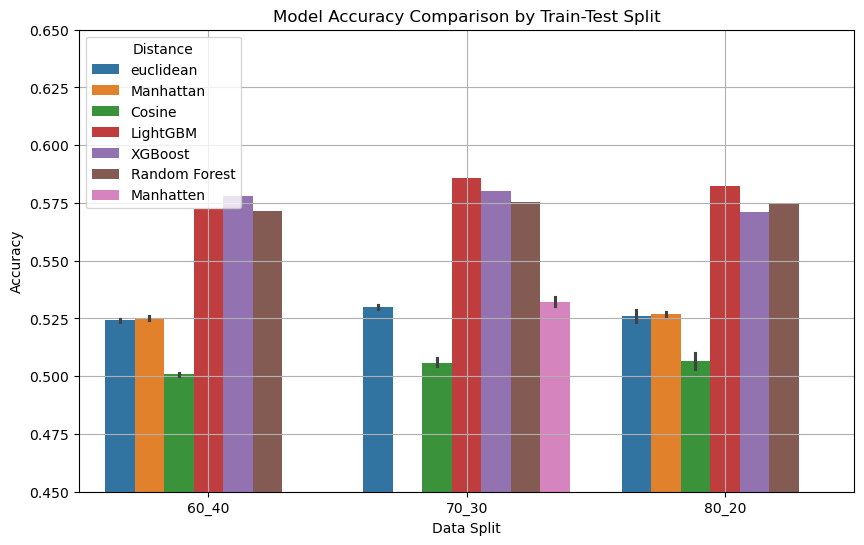

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(data=all_results, x='Split', y='Accuracy', hue='Distance')
plt.title("Model Accuracy Comparison by Train-Test Split")
plt.xlabel("Data Split")
plt.ylabel("Accuracy")
plt.ylim(0.45, 0.65)
plt.grid(True)
plt.show()


This bar chart displays the accuracy of each model (KNN, RF, XGBoost, LightGBM) across the three train-test splits. It helps visualize which algorithm performed best in terms of accuracy, and how the split ratio impacted the performance.

## 🔥 F1-Score Heatmap by Model and Split


In [68]:
# ✅ Fix typos and normalize model names
all_results['Distance'] = all_results['Distance'].replace({
    'Manhatten': 'Manhattan',  # Fix typo
    'euclidean': 'Euclidean',
    'cosine': 'Cosine',
    'Cosine': 'Cosine',
    'Manhattan': 'Manhattan',
    'Euclidean': 'Euclidean',
    'Random Forest': 'Random Forest',
    'XGBoost': 'XGBoost',
    'LightGBM': 'LightGBM'
})


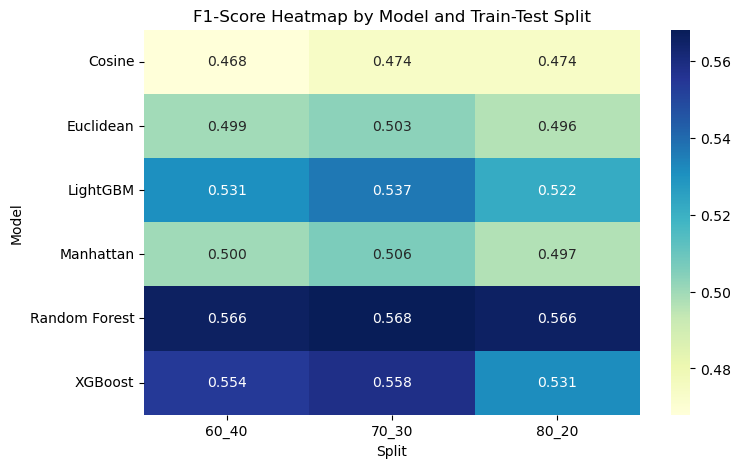

In [69]:
# 🔥 F1-Score Heatmap by Model and Train-Test Split
f1_heatmap = all_results.pivot_table(index='Distance', columns='Split', values='F1-Score', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(f1_heatmap, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("F1-Score Heatmap by Model and Train-Test Split")
plt.xlabel("Split")
plt.ylabel("Model")
plt.show()



This heatmap highlights the F1-Score of each model for each split. The F1-Score balances precision and recall, making it useful especially when the data is slightly imbalanced. This visualization helps identify which model is the most robust across different configurations.